# Finite Difference Testing
1. Testing that taking a trained energy model, `E=lr(X)`, can successfully predict forces: `[lr(X(r+dr)) - lr(X(r)))]/dr = -F(r)`
   * [SOAP](#soap-fd-forces)
   * [AniSOAP](#anisoap-fd-forces) 
2. Testing that the finite difference model `[X(r+dr) - X(r)]/dr` yields the same results as the analytical gradients.
   * [SOAP](#soap-fd)
   * [AniSOAP](#anisoap-fd) 

# SOAP Finite Difference Forces<a class="anchor" id="soap-fd-forces"></a>


In [53]:
from ase.io import read
from metatrain.utils.data import DatasetInfo
from metatrain.utils.data.target_info import get_energy_target_info
from metatrain.utils.data import Dataset
from omegaconf import OmegaConf
from metatrain.utils.data.target_info import get_energy_target_info
# from metatrain.gap import GAP
from metatrain.soap_bpnn import SoapBpnn as BPNN
import torch
from ase.io import read
from metatomic.torch import systems_to_torch
from metatensor.torch import TensorMap, TensorBlock, Labels
from metatrain.utils.data import Dataset
from torch.utils.data import random_split
from metatrain.soap_bpnn import Trainer


In [54]:

target_cfg = OmegaConf.create({
    "quantity": "energy",
    "unit": "eV",
})

energy_info = get_energy_target_info(
    target_name="energy",
    target=target_cfg,
    add_position_gradients=True,
)

dataset_info = DatasetInfo(
    length_unit="angstrom",
    atomic_types=[0],  # H, O
    targets={
        "energy": energy_info
    },
)

In [57]:
lmax=6
nmax=9
HYPER_PARAMETERS = {
    "soap":{
        "cutoff": {
            "radius": 3.0,
            "smoothing": {"type": "ShiftedCosine", "width": 0.5},
        },
        "density": {
            "type": "Gaussian",
            "width": 1.0,
        },
        "basis": {
            "type": "TensorProduct",
            "max_angular": lmax,
            "radial": {"type": "Gto", "max_radial": nmax},
        },
    },
    "krr": {"num_sparse_points": 10, "degree": 1},
    "zbl": False,
    "legacy": False,
    "long_range": {"enable": False},
    "heads": "mlp",
    "add_lambda_basis": False,
    "bpnn": {"num_hidden_layers": 2,
            "num_neurons_per_layer":32,
            "layernorm":True}
}
HYPER_PARAMETERS['soap']['max_angular'] = HYPER_PARAMETERS['soap']['basis']['max_angular']
HYPER_PARAMETERS['soap']['max_radial'] = HYPER_PARAMETERS['soap']['basis']['radial']['max_radial']
HYPER_PARAMETERS["soap"]["cutoff"]["width"] = HYPER_PARAMETERS['soap']['cutoff']['smoothing']['width']
g = BPNN(hypers=HYPER_PARAMETERS, dataset_info=dataset_info)
print(dataset_info.targets["energy"])

TargetInfo(layout=TensorMap with 1 blocks
keys: _
      0, quantity='energy', unit='eV', description='')


In [67]:
frames = read("../benchmarks/two_particle_gb/force_and_torque_benchmarks/all_frames.xyz", ":")

systems = systems_to_torch(frames, dtype=torch.float64)
for system in systems:
    system.positions.requires_grad_(True)

def energy_target(atoms, system_i):
    n_atoms = len(atoms)

    block = TensorBlock(
        values=torch.tensor([[atoms.get_potential_energy()]], dtype=torch.float64),
        samples=Labels(
            ["system"],
            torch.tensor([[system_i]], dtype=torch.int32),
        ),
        components=[],
        properties=Labels(
            ["energy"],
            torch.tensor([[0]], dtype=torch.int32),
        ),
    )

    forces = torch.tensor(atoms.get_forces(), dtype=torch.float64)

    grad_block = TensorBlock(
        values=-forces.reshape(n_atoms, 3, 1),
        samples=Labels(
            ["sample", "atom"],
            torch.tensor(
                [[0, i] for i in range(n_atoms)],
                dtype=torch.int32,
            ),
        ),
        components=[
            Labels(
                ["xyz"],
                torch.tensor([[0], [1], [2]], dtype=torch.int32),
            )
        ],
        properties=block.properties,
    )

    block.add_gradient("positions", grad_block)

    return TensorMap(keys=Labels.single(), blocks=[block])

dataset = Dataset.from_dict({
    "system": systems,
    "energy": [energy_target(atoms, i) for i, atoms in enumerate(frames)],
})

/Users/rca/miniforge3/envs/new_base/lib/python3.11/site-packages/metatomic/torch/systems_to_torch.py:52: UserWarning: A conversion to `System` was requested for an `ase.Atoms` object with one or more non-zero cell vectors but where the corresponding boundary conditions are set to `False`. The corresponding cell vectors will be set to zero.
  return [


In [68]:
n_val = max(1, int(0.1 * len(dataset)))
n_train = len(dataset) - n_val

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(0),
)

trainer = Trainer({
    "regularizer": 1e-3,
    "regularizer_forces": 1e-3,  # or None to use same as energy
    "distributed": False,
    "num_epochs": 100,
    "batch_size": 16,
    "learning_rate": 1e-3,
    "atomic_baseline": {"energy": {0:0}}, 
    "scale_targets": True,
    "fixed_scaling_weights": {"energy": 1.},
    "batch_atom_bounds": [None, None],
    "num_workers": 0,
    "loss": {
        "type": "mse",
        "weights": {
            "energy": 1.0,
            "forces": 10.0,
        },
    },
    "warmup_fraction": 0.1,
    "per_structure_targets": ['energy'],
    "per_atom_targets": ['forces'],
    "log_separate_blocks": True,
    "log_mae": True,
    "log_interval": 1,
    "checkpoint_interval": 1,
    "best_model_metric": "rmse_prod",
})

trainer.train(
    model=g,
    dtype=torch.float64,
    devices=[torch.device("cpu")],
    train_datasets=[train_dataset],
    val_datasets=[val_dataset],
    checkpoint_dir="./model_outputs/",
)

In [69]:
import matplotlib.pyplot as plt
from metatomic.torch import ModelOutput, ModelEvaluationOptions

exported = g.export()

options = ModelEvaluationOptions(
    outputs={
        "energy": ModelOutput(
            quantity="energy",
            unit="eV",
            per_atom=False,
        )
    }
)

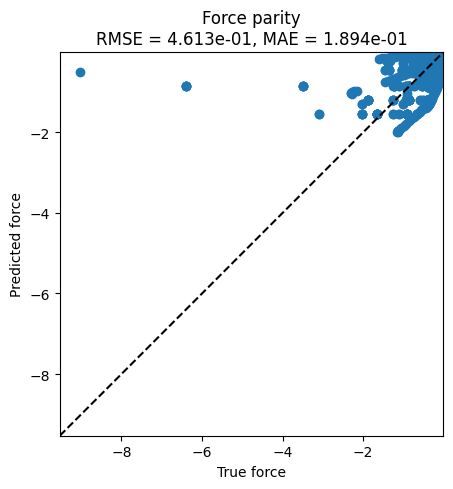

In [77]:
# y_true, y_pred = [], []

# for sample in dataset:
#     pred = exported([sample["system"]], options, check_consistency=True)

#     y_true.append(sample["energy"].block(0).values.item())
#     y_pred.append(pred["energy"].block(0).values.item())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred)
lims = [min(y_true + y_pred), max(y_true + y_pred)]
plt.plot(lims, lims, "k--")
plt.xlabel("True energy")
plt.ylabel("Predicted energy")


rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))


plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal")

plt.xlabel("True force")
plt.ylabel("Predicted force")
plt.title(f"Force parity\nRMSE = {rmse:.3e}, MAE = {mae:.3e}")

plt.tight_layout()
plt.show()

In [74]:
pred = exported(
    [system],
    options,  # energy-only ModelEvaluationOptions
    check_consistency=False,
)

energy = pred["energy"].block(0).values.sum()
energy.backward()

forces_pred = -system.positions.grad
print(forces_pred)

tensor([[ 0.6188,  0.5235,  0.7782],
        [-0.6188, -0.5235, -0.7782]], dtype=torch.float64)


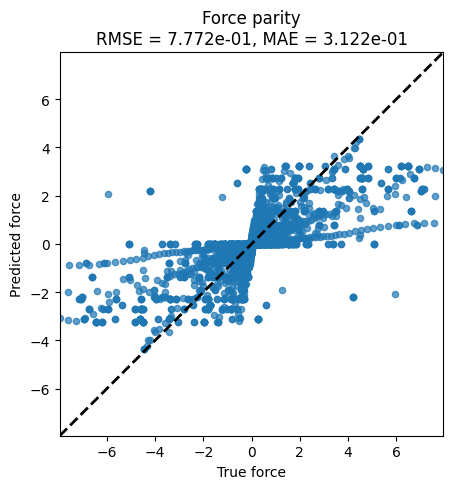

In [75]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch

f_true = []
f_pred = []

for sample in dataset:
    system = copy.deepcopy(sample["system"])
    system.positions.requires_grad_(True)

    pred = exported(
        [system],
        options,  # energy-only options
        check_consistency=False,
    )

    energy = pred["energy"].block(0).values.sum()
    energy.backward()

    forces_pred = -system.positions.grad.detach()

    forces_true = -sample["energy"] \
        .block(0) \
        .gradient("positions") \
        .values \
        .squeeze(-1)

    f_pred.append(forces_pred.cpu().numpy().ravel())
    f_true.append(forces_true.cpu().numpy().ravel())

f_true = np.concatenate(f_true)
f_pred = np.concatenate(f_pred)

rmse = np.sqrt(np.mean((f_true - f_pred) ** 2))
mae = np.mean(np.abs(f_true - f_pred))

plt.figure(figsize=(5, 5))
plt.scatter(f_true, f_pred, s=20, alpha=0.7)

lims = [
    min(f_true.min(), f_pred.min()),
    max(f_true.max(), f_pred.max()),
]

plt.plot(lims, lims, "k--", lw=2)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal")

plt.xlabel("True force")
plt.ylabel("Predicted force")
plt.title(f"Force parity\nRMSE = {rmse:.3e}, MAE = {mae:.3e}")

plt.tight_layout()
plt.show()